# Model B — Temporal Sequence Model (Weeks 3-4)

Extracts a short temporal window per pedestrian (not just the final frame) and trains a small LSTM on top of per-frame MobileNetV2 features, per the thesis plan's Model B spec.

**Design choice flagged up front:** the plan describes a 2.0s window at 30 FPS (~60 frames, stride 2 to 30). Storing and training on 30 full frames per sample is expensive for both Drive storage and Colab GPU memory within a single session. This notebook uses **T=16 frames, evenly sampled across each pedestrian's available track**, as a pragmatic middle ground, this is a deviation worth noting in your methodology section, not a hidden shortcut. If training is stable and time allows, T can be increased later.

**Backbone choice:** MobileNetV2 is used as a **frozen** per-frame feature extractor (ImageNet pretrained, no fine-tuning) to keep training fast and the model genuinely lightweight, only the LSTM and classifier head are trained. This matches the thesis plan's framing of Model B as a lightweight extension of Model A, not a full end-to-end retrain.

## 1. Setup (same as Model A)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys
DRIVE_ROOT = '/content/drive/MyDrive/PIE_thesis'
PIE_DATA_ROOT = f'{DRIVE_ROOT}/PIE_dataset'
CROPS_DIR = f'{DRIVE_ROOT}/crops'
RESULTS_DIR = f'{DRIVE_ROOT}/results'
CHECKPOINTS_DIR = f'{DRIVE_ROOT}/checkpoints'
for d in [RESULTS_DIR, CHECKPOINTS_DIR]:
    os.makedirs(d, exist_ok=True)

if not os.path.exists('/content/PIE_repo'):
    get_ipython().system('git clone https://github.com/aras62/PIE.git /content/PIE_repo')
if '/content/PIE_repo/utilities' not in sys.path:
    sys.path.append('/content/PIE_repo/utilities')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as T
import numpy as np
import h5py
import cv2
import re
import random
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import pandas as pd

device = torch.device('mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu'))
print('Device:', device)


Mounted at /content/drive
Cloning into '/content/PIE_repo'...
remote: Enumerating objects: 181, done.
remote: Counting objects: 100% (96/96), done.
remote: Compressing objects: 100% (76/76), done.
remote: Total 181 (delta 35), reused 75 (delta 18), pack-reused 85 (from 1)
Receiving objects: 100% (181/181), 144.63 MiB | 18.81 MiB/s, done.
Resolving deltas: 100% (76/76), done.
Updating files: 100% (41/41), done.
Device: cuda


## 2. Load PIE sequences (reuses the cached database from Week 1, fast)

In [2]:
from pie_data import PIE

imdb = PIE(data_path=PIE_DATA_ROOT)
data_opts = {'seq_type': 'crossing', 'data_split_type': 'default'}

train_seqs = imdb.generate_data_trajectory_sequence('train', **data_opts)
val_seqs = imdb.generate_data_trajectory_sequence('val', **data_opts)
test_seqs = imdb.generate_data_trajectory_sequence('test', **data_opts)

print('Sequences:', len(train_seqs['pid']), len(val_seqs['pid']), len(test_seqs['pid']))

CROSS_KEY = 'activities'  # confirmed in Week 1
IRRELEVANT_VALUE = -1

clips_root = f'{PIE_DATA_ROOT}/PIE_clips'


---------------------------------------------------------
Generating trajectory sequence data
fstride: 1
sample_type: all
height_rng: [0, inf]
squarify_ratio: 0
data_split_type: default
seq_type: crossing
min_track_size: 15
random_params: {'ratios': None, 'val_data': True, 'regen_data': False}
kfold_params: {'num_folds': 5, 'fold': 1}
---------------------------------------------------------
Generating database for pie
pie annotations loaded from /content/drive/MyDrive/PIE_thesis/PIE_dataset/data_cache/pie_database.pkl
---------------------------------------------------------
Generating crossing data
Excluding tracks with less than 15
Subset: train
Number of pedestrians: 880 
Total number of samples: 876 
---------------------------------------------------------
Generating trajectory sequence data
fstride: 1
sample_type: all
height_rng: [0, inf]
squarify_ratio: 0
data_split_type: default
seq_type: crossing
min_track_size: 15
random_params: {'ratios': None, 'val_data': True, 'regen_data

## 3. Extract T-frame temporal crops to HDF5

Reuses `_resolve_video_path` from Week 1. For each sample, picks `T_FRAMES` evenly spaced frame indices across that pedestrian's available track (not just the last frame), crops each to the bbox at that frame, resizes, and stacks into one `(T, 224, 224, 3)` array.

**Storage estimate:** roughly 876+243+717 samples x 16 frames x 224x224x3 bytes ≈ 4.4GB total across the three split files. Confirm Drive has headroom before running.

In [3]:
from tqdm.notebook import tqdm

IMG_SIZE = 224
T_FRAMES = 16

def _resolve_video_path(image_ref):
    parts = image_ref.replace('\\', '/').split('/')
    set_id = next((p for p in parts if re.match(r'set\d+', p)), None)
    video_id = next((p for p in parts if re.match(r'video_\d+', p)), None)
    frame_num = int(re.sub(r'\D', '', parts[-1]))
    video_path = f'{clips_root}/{set_id}/{video_id}.mp4'
    return video_path, frame_num

def _unwrap_label(label):
    while isinstance(label, list):
        label = label[-1]
    return label

def _sample_indices(n_available, t_frames):
    if n_available <= t_frames:
        return list(range(n_available))
    return sorted(set(np.linspace(0, n_available - 1, t_frames).astype(int).tolist()))

def extract_temporal_split_to_hdf5(seqs, cross_key, irrelevant_value, t_frames, out_path):
    sample_meta = []
    for i in range(len(seqs['pid'])):
        labels = seqs[cross_key][i]
        label = _unwrap_label(labels[-1] if isinstance(labels, list) else labels)
        if label == irrelevant_value:
            continue
        sample_meta.append({'seq_i': i, 'label': int(label)})

    n_samples = len(sample_meta)

    if os.path.exists(out_path):
        hf = h5py.File(out_path, 'a')
        completed = hf['completed'][:]
        print(f'Resuming {out_path}: {int(completed.sum())}/{n_samples} already done')
    else:
        hf = h5py.File(out_path, 'w')
        hf.create_dataset('images', shape=(n_samples, t_frames, IMG_SIZE, IMG_SIZE, 3), dtype='uint8')
        hf.create_dataset('labels', shape=(n_samples,), dtype='int64')
        hf.create_dataset('completed', shape=(n_samples,), dtype='bool')
        for idx, meta in enumerate(sample_meta):
            hf['labels'][idx] = meta['label']
        hf['completed'][:] = False
        hf.flush()
        completed = hf['completed'][:]
        print(f'Starting fresh: 0/{n_samples} for {out_path}')

    video_cache = {}
    n_done_now = 0
    pbar = tqdm(range(n_samples), desc=os.path.basename(out_path))
    for idx in pbar:
        if completed[idx]:
            continue
        meta = sample_meta[idx]
        i = meta['seq_i']
        image_refs = seqs['image'][i]
        bboxes = seqs['bbox'][i]
        n_available = len(image_refs)
        idxs = _sample_indices(n_available, t_frames)
        frames_out = np.zeros((t_frames, IMG_SIZE, IMG_SIZE, 3), dtype='uint8')
        for slot, frame_idx in enumerate(idxs):
            image_ref = image_refs[frame_idx]
            bbox = bboxes[frame_idx]
            video_path, frame_num = _resolve_video_path(image_ref)
            if video_path not in video_cache:
                video_cache[video_path] = cv2.VideoCapture(video_path)
            cap = video_cache[video_path]
            cap.set(cv2.CAP_PROP_POS_FRAMES, frame_num)
            ok, frame = cap.read()
            if not ok:
                continue
            x1, y1, x2, y2 = [int(v) for v in bbox]
            crop = frame[max(y1,0):y2, max(x1,0):x2]
            if crop.size == 0:
                continue
            crop = cv2.resize(crop, (IMG_SIZE, IMG_SIZE))
            crop = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
            frames_out[slot] = crop
        hf['images'][idx] = frames_out
        hf['completed'][idx] = True
        n_done_now += 1
        if n_done_now % 20 == 0:
            hf.flush()

    hf.flush()
    hf.close()
    for cap in video_cache.values():
        cap.release()
    print(f'Done: {n_samples} samples written to {out_path}')
    return n_samples

for split_name, seqs in [('train', train_seqs), ('val', val_seqs), ('test', test_seqs)]:
    out_path = f'{CROPS_DIR}/{split_name}_temporal_crops.h5'
    extract_temporal_split_to_hdf5(seqs, CROSS_KEY, IRRELEVANT_VALUE, T_FRAMES, out_path)

Resuming /content/drive/MyDrive/PIE_thesis/crops/train_temporal_crops.h5: 876/876 already done


train_temporal_crops.h5:   0%|          | 0/876 [00:00<?, ?it/s]

Done: 876 samples written to /content/drive/MyDrive/PIE_thesis/crops/train_temporal_crops.h5
Resuming /content/drive/MyDrive/PIE_thesis/crops/val_temporal_crops.h5: 243/243 already done


val_temporal_crops.h5:   0%|          | 0/243 [00:00<?, ?it/s]

Done: 243 samples written to /content/drive/MyDrive/PIE_thesis/crops/val_temporal_crops.h5
Resuming /content/drive/MyDrive/PIE_thesis/crops/test_temporal_crops.h5: 717/717 already done


test_temporal_crops.h5:   0%|          | 0/717 [00:00<?, ?it/s]

Done: 717 samples written to /content/drive/MyDrive/PIE_thesis/crops/test_temporal_crops.h5


In [8]:
import os
for f in ['train_temporal_crops.h5', 'val_temporal_crops.h5', 'test_temporal_crops.h5']:
    p = f'{CROPS_DIR}/{f}'
    if os.path.exists(p):
        os.remove(p)
        print('removed', p)

## 4. Dataset: reads (T, H, W, C) sequences, same-flip-per-sample augmentation

In [4]:
normalize = T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

class PIETemporalDataset(Dataset):
    def __init__(self, h5_path, train=False):
        self.h5_path = h5_path
        self.train = train
        with h5py.File(h5_path, 'r') as hf:
            self.length = hf['images'].shape[0]
            self.t_frames = hf['images'].shape[1]
        self._hf = None

    def _ensure_open(self):
        if self._hf is None:
            self._hf = h5py.File(self.h5_path, 'r')

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        self._ensure_open()
        frames = self._hf['images'][idx]
        label = int(self._hf['labels'][idx])
        flip = self.train and random.random() < 0.5
        out = torch.zeros(self.t_frames, 3, IMG_SIZE, IMG_SIZE)
        for t in range(self.t_frames):
            img = torch.from_numpy(frames[t]).permute(2, 0, 1).float() / 255.0
            if flip:
                img = torch.flip(img, dims=[2])
            out[t] = normalize(img)
        return out, label

train_ds = PIETemporalDataset(f'{CROPS_DIR}/train_temporal_crops.h5', train=True)
val_ds = PIETemporalDataset(f'{CROPS_DIR}/val_temporal_crops.h5')
test_ds = PIETemporalDataset(f'{CROPS_DIR}/test_temporal_crops.h5')
print('Dataset sizes:', len(train_ds), len(val_ds), len(test_ds))
print('T frames:', train_ds.t_frames)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=2)


Dataset sizes: 876 243 717
T frames: 16


## 5. Class weights (reuse same approach as Model A)

In [5]:
with h5py.File(f'{CROPS_DIR}/train_temporal_crops.h5', 'r') as hf:
    train_labels = hf['labels'][:]

unique, counts = np.unique(train_labels, return_counts=True)
print('Train class distribution:', dict(zip(unique.tolist(), counts.tolist())))
class_weights = torch.tensor([len(train_labels) / c for c in counts], dtype=torch.float32).to(device)
print('Class weights:', class_weights)


Train class distribution: {0: 623, 1: 253}
Class weights: tensor([1.4061, 3.4625], device='cuda:0')


## 6. Model: frozen MobileNetV2 feature extractor + LSTM + classifier

Backbone runs per-frame (no grad), producing a 1280-d feature vector per frame; the LSTM aggregates across the T frames; a dropout + linear head gives the final crossing/not-crossing prediction.

In [6]:
backbone = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT).features
backbone = backbone.to(device)
backbone.eval()
for p in backbone.parameters():
    p.requires_grad = False

FEATURE_DIM = 1280
HIDDEN_DIM = 128

class TemporalModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size=FEATURE_DIM, hidden_size=HIDDEN_DIM, num_layers=1, batch_first=True)
        self.dropout = nn.Dropout(p=0.5)
        self.classifier = nn.Linear(HIDDEN_DIM, 2)

    def forward(self, features):
        _, (h_n, _) = self.lstm(features)
        out = self.dropout(h_n[-1])
        return self.classifier(out)

def extract_features(frames_batch):
    b, t, c, h, w = frames_batch.shape
    flat = frames_batch.view(b * t, c, h, w)
    with torch.no_grad():
        feats = backbone(flat)
        feats = nn.functional.adaptive_avg_pool2d(feats, 1).view(b * t, -1)
    return feats.view(b, t, -1)

model = TemporalModel().to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
print(model)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 59.5MB/s]


TemporalModel(
  (lstm): LSTM(1280, 128, batch_first=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (classifier): Linear(in_features=128, out_features=2, bias=True)
)


## 7. Train (same regularization pattern as the fixed Model A: best checkpoint + early stopping)

In [7]:
EPOCHS = 20
PATIENCE = 5

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, n = 0.0, 0
    all_preds, all_labels = [], []
    with torch.set_grad_enabled(train):
        for frames, y in loader:
            frames, y = frames.to(device), y.to(device)
            feats = extract_features(frames)
            if train:
                optimizer.zero_grad()
            out = model(feats)
            loss = criterion(out, y)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * frames.size(0)
            n += frames.size(0)
            preds = out.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    return total_loss / max(n, 1), f1

history = []
best_val_f1 = 0.0
patience_counter = 0
for epoch in range(EPOCHS):
    train_loss, train_f1 = run_epoch(train_loader, train=True)
    val_loss, val_f1 = run_epoch(val_loader, train=False)
    print(f'Epoch {epoch+1}/{EPOCHS}  train_loss={train_loss:.4f} train_f1={train_f1:.4f}  val_loss={val_loss:.4f} val_f1={val_f1:.4f}')
    history.append({'epoch': epoch+1, 'train_loss': train_loss, 'train_f1': train_f1, 'val_loss': val_loss, 'val_f1': val_f1})
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        patience_counter = 0
        torch.save(model.state_dict(), f'{CHECKPOINTS_DIR}/model_b_temporal.pt')
        print(f'  New best val_f1={val_f1:.4f}, checkpoint saved')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'Early stopping at epoch {epoch+1}, best val_f1={best_val_f1:.4f}')
            break

print('Training done, best val_f1:', best_val_f1)


Epoch 1/20  train_loss=0.5104 train_f1=0.6452  val_loss=0.5259 val_f1=0.6000
  New best val_f1=0.6000, checkpoint saved
Epoch 2/20  train_loss=0.2879 train_f1=0.8333  val_loss=0.4686 val_f1=0.6720
  New best val_f1=0.6720, checkpoint saved
Epoch 3/20  train_loss=0.1817 train_f1=0.9017  val_loss=0.4072 val_f1=0.7049
  New best val_f1=0.7049, checkpoint saved
Epoch 4/20  train_loss=0.1316 train_f1=0.9441  val_loss=0.4309 val_f1=0.7500
  New best val_f1=0.7500, checkpoint saved
Epoch 5/20  train_loss=0.0943 train_f1=0.9518  val_loss=0.4608 val_f1=0.7455
Epoch 6/20  train_loss=0.0622 train_f1=0.9669  val_loss=0.4450 val_f1=0.7593
  New best val_f1=0.7593, checkpoint saved
Epoch 7/20  train_loss=0.0450 train_f1=0.9784  val_loss=0.4796 val_f1=0.7257
Epoch 8/20  train_loss=0.0380 train_f1=0.9786  val_loss=0.6050 val_f1=0.7500
Epoch 9/20  train_loss=0.0125 train_f1=0.9980  val_loss=0.5791 val_f1=0.7477
Epoch 10/20  train_loss=0.0066 train_f1=1.0000  val_loss=0.6400 val_f1=0.7387
Epoch 11/20  t

## 8. Evaluate on held-out test set (same metrics as Model A, for direct comparison)

In [8]:
model.load_state_dict(torch.load(f'{CHECKPOINTS_DIR}/model_b_temporal.pt'))
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for frames, y in test_loader:
        frames = frames.to(device)
        feats = extract_features(frames)
        out = model(feats)
        preds = out.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y.numpy())

f1 = f1_score(all_labels, all_preds, zero_division=0)
precision = precision_score(all_labels, all_preds, zero_division=0)
recall = recall_score(all_labels, all_preds, zero_division=0)
cm = confusion_matrix(all_labels, all_preds)
tn, fp, fn, tp = cm.ravel()
fnr = fn / (fn + tp) if (fn + tp) > 0 else float('nan')
fpr = fp / (fp + tn) if (fp + tn) > 0 else float('nan')

results = {'model': 'Model B - Temporal LSTM', 'f1': f1, 'precision': precision,
           'recall': recall, 'false_negative_rate': fnr, 'false_positive_rate': fpr}
print(results)
print(classification_report(all_labels, all_preds, target_names=['not-crossing', 'crossing']))


{'model': 'Model B - Temporal LSTM', 'f1': 0.7865707434052758, 'precision': 0.7735849056603774, 'recall': 0.8, 'false_negative_rate': np.float64(0.2), 'false_positive_rate': np.float64(0.09375)}
              precision    recall  f1-score   support

not-crossing       0.92      0.91      0.91       512
    crossing       0.77      0.80      0.79       205

    accuracy                           0.88       717
   macro avg       0.85      0.85      0.85       717
weighted avg       0.88      0.88      0.88       717



## 9. Figures, including a direct comparison against Model A

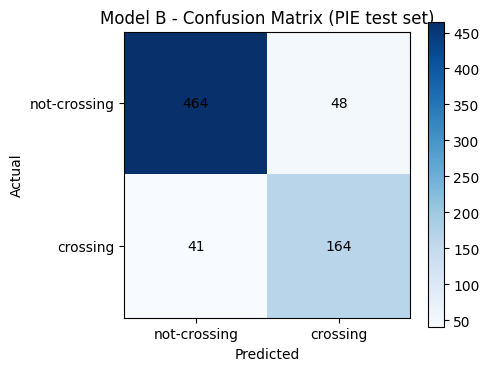

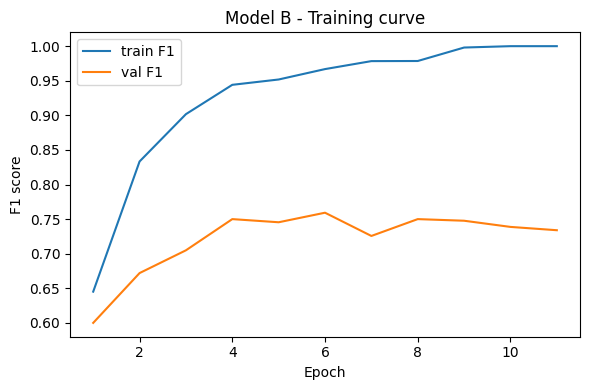

In [9]:
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_xticklabels(['not-crossing', 'crossing'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['not-crossing', 'crossing'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Model B - Confusion Matrix (PIE test set)')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='black')
plt.colorbar(im)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/model_b_confusion_matrix.png', dpi=150)
plt.show()

metrics_df = pd.DataFrame([results])
metrics_df.to_csv(f'{RESULTS_DIR}/model_b_test_metrics.csv', index=False)
history_df = pd.DataFrame(history)
history_df.to_csv(f'{RESULTS_DIR}/model_b_training_history.csv', index=False)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(history_df['epoch'], history_df['train_f1'], label='train F1')
ax.plot(history_df['epoch'], history_df['val_f1'], label='val F1')
ax.set_xlabel('Epoch'); ax.set_ylabel('F1 score')
ax.set_title('Model B - Training curve')
ax.legend()
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/model_b_training_curve.png', dpi=150)
plt.show()


                                model        f1  precision    recall
0  Model A - Single-Frame MobileNetV2  0.794737   0.862857  0.736585
1             Model B - Temporal LSTM  0.786571   0.773585  0.800000


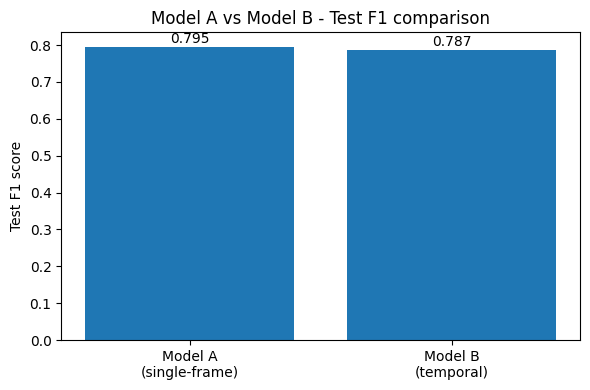

In [10]:
# Direct comparison against Model A, reads the Model A results already saved in Week 2
try:
    model_a_df = pd.read_csv(f'{RESULTS_DIR}/model_a_test_metrics.csv')
    compare_df = pd.concat([model_a_df, metrics_df], ignore_index=True)
    print(compare_df[['model', 'f1', 'precision', 'recall']])

    fig, ax = plt.subplots(figsize=(6, 4))
    x = np.arange(len(compare_df))
    ax.bar(x, compare_df['f1'])
    ax.set_xticks(x); ax.set_xticklabels(['Model A\n(single-frame)', 'Model B\n(temporal)'])
    ax.set_ylabel('Test F1 score')
    ax.set_title('Model A vs Model B - Test F1 comparison')
    for i, v in enumerate(compare_df['f1']):
        ax.text(i, v + 0.01, f'{v:.3f}', ha='center')
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/model_a_vs_b_comparison.png', dpi=150)
    plt.show()
except FileNotFoundError:
    print('Model A results not found, skipping comparison plot.')


## 10. Go/No-Go and commit

Compare Model B's test F1 against Model A's 0.795. Per the thesis plan, this is the core research question, does temporal information improve early crossing prediction over single-frame perception.

```bash
cd pedestrian-crossing-prediction
cp <RESULTS_DIR>/model_b_*.csv results/
cp <RESULTS_DIR>/model_b_*.png results/
cp <RESULTS_DIR>/model_a_vs_b_comparison.png results/
git add results/ notebooks/week3_model_b_temporal.ipynb
git commit -m "Weeks 3-4: Model B temporal LSTM trained and evaluated, compared against Model A baseline"
git push
```